In [2]:
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
import librosa 
import pytimbre as pt

In [3]:
FILE_PATH = r"corpus\metro_sample_2.wav"

In [74]:
audio, sr = sf.read(FILE_PATH) #multi channel output
audio.shape, sr

((4499456, 2), 48000)

48kHz sr, so 48k samples per second. So, a 1 ms or 10 ms grain will contain 48 samples or 480 samples respectively

### 1. The analysis of the audio and its grains

In [41]:
y,sr = librosa.load(FILE_PATH, sr=48000)

c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\hippo\AppData\Local\Temp\ipykernel_16924\4057964191.py:1: UserWarning: PySoundFile failed. Trying audioread instead.
  y,sr = librosa.load(FILE_PATH, sr=48000)
c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: 'corpus\\metro_sample.wav'

In [ ]:
y.shape, sr

((4499456,), 48000)

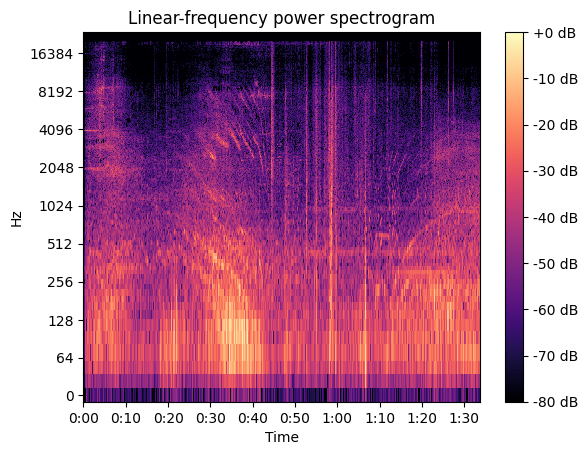

In [5]:
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
fig, ax = plt.subplots()
img = librosa.display.specshow(data=D,y_axis='log', x_axis='time', sr=sr, ax=ax)
ax.set(title='Linear-frequency power spectrogram')
ax.label_outer()
fig.colorbar(img, ax=ax, format="%+2.f dB")


Using flucoma's fluid-noveltyslicer CLI tools to extract novel slice indices

In [38]:
import subprocess

command = [
    "fluid-noveltyslice",
    "-source", r"corpus\metro_sample_2.wav",
    "-indices", "indices.csv"
]

try:
    result = subprocess.run(
        command, 
        check=True,          # Raises CalledProcessError if the exit code is non-zero
        capture_output=True, # Captures stdout and stderr
        text=True            # Returns output as strings instead of bytes
    )
    print("Command Output:\n", result.stdout)

except subprocess.CalledProcessError as e:
    print(f"An error occurred while running fluid-noveltyslice: {e}")
    print("Error details:", e.stderr)

Command Output:
   6%
 18%
 29%
 40%
 52%
 63%
 75%
 87%
 99%
100%



Extracting the MFCC coefficients for each grain. Each grain is now 480 samples, i.e. 100 ms long (at most)

In [39]:
import csv
with open('indices.csv', 'r') as f:
    slice_indices = np.array([int(i) for i in list(csv.reader(f))[0]])
slice_indices

array([   9216,  410112,  869888,  873984,  875520,  882176,  914432,
        921600,  923648, 1033216, 1047552, 1142784, 1552384, 1637888,
       1694720, 1743360, 1843712, 2019840, 2326016, 2329600, 2403328,
       2463232, 2490880, 2497024, 2534912, 2763264, 2765824, 2781696,
       2816512, 2830848, 2839552, 2847744, 2902016, 2916864, 2966016,
       2979840, 3047424, 3086336, 3101696, 3111936, 3130880, 3319808,
       3446784, 3487232, 3574784, 3585536, 3597312, 3623936, 3870208,
       4007424, 4011008, 4040192, 4048384, 4128256, 4162048, 4166656,
       4174336, 4270592, 4346880, 4405760, 4422144])

if sr is 48kHz, if I want 480 max, then, I can do index:index+480

In [75]:
grains = []
audio_mono = np.mean(audio, axis=1)
audio_len = len(audio_mono)
for index in slice_indices:
    grain_end = index+480
    if grain_end > audio_len:
        grain_end = audio_len
    grains.append((index, grain_end))
grains

[(np.int64(9216), np.int64(9696)),
 (np.int64(410112), np.int64(410592)),
 (np.int64(869888), np.int64(870368)),
 (np.int64(873984), np.int64(874464)),
 (np.int64(875520), np.int64(876000)),
 (np.int64(882176), np.int64(882656)),
 (np.int64(914432), np.int64(914912)),
 (np.int64(921600), np.int64(922080)),
 (np.int64(923648), np.int64(924128)),
 (np.int64(1033216), np.int64(1033696)),
 (np.int64(1047552), np.int64(1048032)),
 (np.int64(1142784), np.int64(1143264)),
 (np.int64(1552384), np.int64(1552864)),
 (np.int64(1637888), np.int64(1638368)),
 (np.int64(1694720), np.int64(1695200)),
 (np.int64(1743360), np.int64(1743840)),
 (np.int64(1843712), np.int64(1844192)),
 (np.int64(2019840), np.int64(2020320)),
 (np.int64(2326016), np.int64(2326496)),
 (np.int64(2329600), np.int64(2330080)),
 (np.int64(2403328), np.int64(2403808)),
 (np.int64(2463232), np.int64(2463712)),
 (np.int64(2490880), np.int64(2491360)),
 (np.int64(2497024), np.int64(2497504)),
 (np.int64(2534912), np.int64(2535392)

In [47]:
for g in grains:
    g[0] + 1
    break

In [82]:
grains_mfccs = []
for grain in grains:
    s, e = grain
    data = audio_mono[s:e]
    grain_mfcc = librosa.feature.mfcc(y=audio_mono[s:e], sr=sr)
    grains_mfccs.append(grain_mfcc)




In [84]:
grains_mfccs[5]

array([[-282.93013268],
       [ 136.25640897],
       [  18.4871334 ],
       [  10.55062495],
       [  16.82446358],
       [   5.09928478],
       [  14.01190045],
       [   5.59851822],
       [   9.39599703],
       [ -10.03944647],
       [  -6.02353038],
       [  -3.09769325],
       [   6.27020454],
       [   5.01465343],
       [   8.39756421],
       [   9.71853524],
       [   4.57486158],
       [   4.66136136],
       [  -2.01107254],
       [   4.82891094]])

In [85]:
for mfcc in grains_mfccs:
    print(mfcc.shape)

(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)
(20, 1)


Plotting centroid x rolloff

In [105]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [113]:
descriptors = []
for grain in grains:
    s, e = grain
    data = audio_mono[s:e]
    spectral_centroid = librosa.feature.spectral_centroid(y=data, sr=sr)
    spectroll_rolloff = librosa.feature.spectral_rolloff(y=data, sr=sr)
    descr = float(spectral_centroid), float(spectroll_rolloff)
    descriptors.append(descr)


c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=480
  warnings.warn(
C:\Users\hippo\AppData\Local\Temp\ipykernel_16924\4073138305.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  descr = float(spectral_centroid), float(spectroll_rolloff)


In [4]:
from sklearn.preprocessing import normalize

In [131]:
arr = np.array(descriptors)
arr_norm = normalize(arr, norm="l2")
arr, arr_norm

(array([[    0.        ,     0.        ],
        [ 4055.25414681,  8578.125     ],
        [ 2897.04396913,  5039.0625    ],
        [ 2841.61467172,  6023.4375    ],
        [ 3291.60832045,  7101.5625    ],
        [ 4093.61481402, 10851.5625    ],
        [ 5028.28578968, 19125.        ],
        [ 2002.66627129,  2179.6875    ],
        [ 5037.52222558, 14695.3125    ],
        [ 1879.943212  ,  2414.0625    ],
        [ 3855.53392064,  9164.0625    ],
        [ 2825.75216016,  4289.0625    ],
        [ 4454.24740674, 10945.3125    ],
        [ 4284.49412487, 10992.1875    ],
        [ 2268.31301221,  4007.8125    ],
        [ 2263.92277142,  3773.4375    ],
        [ 4084.00838057,  8718.75      ],
        [ 4981.40668691,  9210.9375    ],
        [ 3689.37566123,  7921.875     ],
        [ 4040.72910504,  9539.0625    ],
        [ 6838.33499362, 19664.0625    ],
        [ 4146.94706171,  9445.3125    ],
        [ 4885.36823558, 17132.8125    ],
        [ 4848.61004536, 11273.437

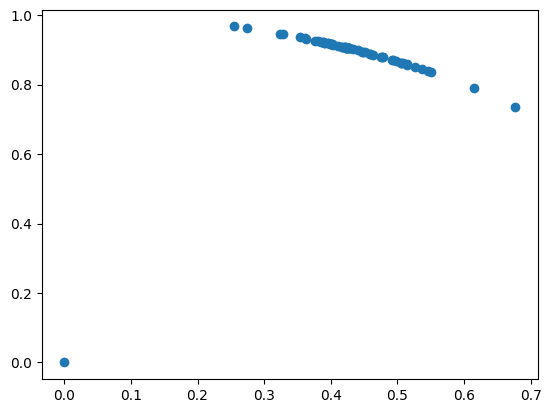

In [132]:
plt.scatter(arr_norm[:, 0], arr_norm[:, 1])

we reduce the 20 coeffs down to two values using UMAP and display the grains dispersed across time

In [ ]:
import umap

In [58]:
reducer = umap.UMAP()

In [89]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from umap import UMAP
import matplotlib.pyplot as plt

In [93]:
# Each (20, 1) becomes a row in a (n, 20) matrix
data_matrix = np.stack([mfcc.flatten() for mfcc in grains_mfccs]) 
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(data_matrix)

reducer = UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42)
embedding = reducer.fit_transform(data_matrix)

c:\Users\hippo\miniconda3\envs\fieldmusic\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


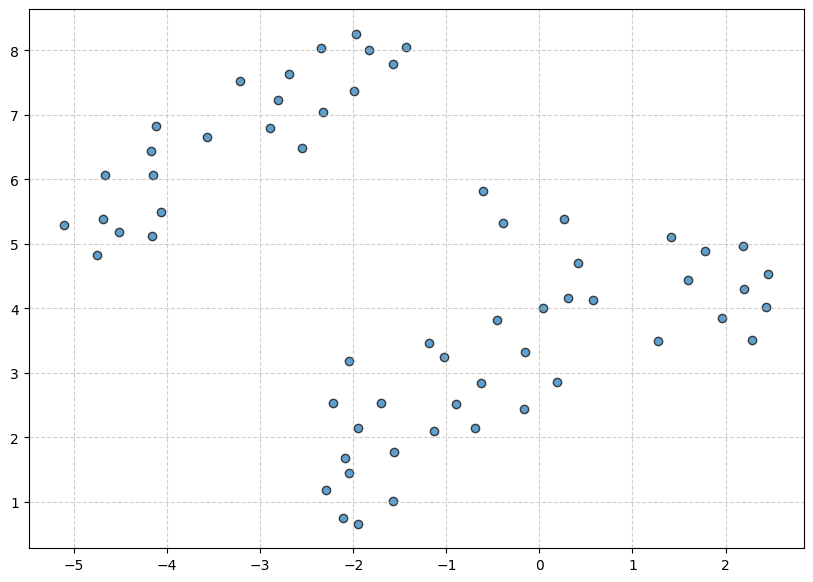

In [95]:
plt.figure(figsize=(10, 7))
plt.scatter(embedding[:, 0], embedding[:, 1], edgecolors='k', alpha=0.7)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 2. making the granular synth, basic architecture

In [5]:
import csv
with open('indices.csv', 'r') as f:
    slice_indices = np.array([int(i) for i in list(csv.reader(f))[0]])
slice_indices

array([   9216,  410112,  869888,  873984,  875520,  882176,  914432,
        921600,  923648, 1033216, 1047552, 1142784, 1552384, 1637888,
       1694720, 1743360, 1843712, 2019840, 2326016, 2329600, 2403328,
       2463232, 2490880, 2497024, 2534912, 2763264, 2765824, 2781696,
       2816512, 2830848, 2839552, 2847744, 2902016, 2916864, 2966016,
       2979840, 3047424, 3086336, 3101696, 3111936, 3130880, 3319808,
       3446784, 3487232, 3574784, 3585536, 3597312, 3623936, 3870208,
       4007424, 4011008, 4040192, 4048384, 4128256, 4162048, 4166656,
       4174336, 4270592, 4346880, 4405760, 4422144])

In [35]:
np.random.seed(11111)

In [41]:
def granular_synthesizer(input_audio, output_audio, slice_indices, density, pos_shift:int):
    """ 
    
    density: the number of grains per second, i.e. frequency Hz
    example, if 8 grains per second, then evenly distributed 
    1 second here is 48000 samples. Then, 8 grains interspersed over 48k samples
    """


    y, sr = sf.read(input_audio)
    output_buffer = np.zeros(len(y)) #output buffer 

    if y.ndim > 1:
        y = np.mean(y, axis=1) # make mono if not alrdy
    audio_len = len(y)

    n_grains = audio_len//480
    
    if not slice_indices:
        slice_indices = np.array(
            [i*480 for i in range(n_grains)]
        )
        slice_indices = np.random.choice(slice_indices, 20, replace=False)

    pos_chunks = audio_len//density
    for index in slice_indices:
        grain_end = index+np.random.choice(list(range(48,4800)))
        if grain_end > audio_len:
            grain_end = audio_len
        s, e = index, grain_end
        new_data = y[s: e]
        # TODO: add hanning window 
        sd.play(new_data,sr)
        sd.wait
        
        for i in range(density):
            pos_s = (pos_chunks*(i+1)) + np.random.choice(list(range(-pos_shift, pos_shift)))
            pos_s = np.clip(pos_s, a_min=0, a_max=audio_len-1)
            pos_e = np.clip(pos_s+ (e-s), a_min=0, a_max=audio_len-1)
            if len(new_data) > pos_e-pos_s:
                new_data = new_data[:pos_e-pos_s]
            output_buffer[pos_s: pos_e] += new_data
    # output_norm = normalize(output_buffer, norm="l1")
        

    # TODO: add the grains in the buffer at some density, and some (stochastic) spacing, 
    # TODO: then, layer them and normalize the final output.  
    sf.write(output_audio, output_buffer,sr)
    
granular_synthesizer(
    input_audio=FILE_PATH,
    output_audio="output/output_2.wav",
    slice_indices=None,
    density=2000,
    pos_shift=300
)

In [26]:
import sounddevice as sd

In [33]:
def play_grains(input_audio, output_audio, slice_indices, density, pos_shift:int):
    """ 
    
    density: the number of grains per second, i.e. frequency Hz
    example, if 8 grains per second, then evenly distributed 
    1 second here is 48000 samples. Then, 8 grains interspersed over 48k samples
    """
    y, sr = sf.read(input_audio)
    output_buffer = np.zeros(len(y)) #output buffer 

    if y.ndim > 1:\
        y = np.mean(y, axis=1) # make mono if not alrdy
    audio_len = len(y)
    pos_chunks = audio_len//density
    for index in slice_indices:
        grain_end = index+np.random.choice(list(range(48,480)))
        if grain_end > audio_len:
            grain_end = audio_len
        s, e = index, grain_end
        new_data = y[s: e]
        sd.play(new_data,sr)
        sd.wait
        
    # output_norm = normalize(output_buffer, norm="l1")
        

    # TODO: add the grains in the buffer at some density, and some (stochastic) spacing, 
    # TODO: then, layer them and normalize the final output.  
    # sf.write(output_audio, output_buffer,sr)
    
granular_synthesizer(
    input_audio=FILE_PATH,
    output_audio="output/output_1.wav",
    slice_indices=slice_indices,
    density=3000,
    pos_shift=300
)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [29]:
y, sr = sf.read(FILE_PATH)

if y.ndim > 1:
    y = np.mean(y, axis=1) # make mono if not alrdy
audio_len = len(y)
for index in slice_indices:
    grain_end = index+np.random.choice(list(range(48,480)))
    if grain_end > audio_len:
        grain_end = audio_len
    s, e = index, grain_end
    new_data = y[s: e]
    sd.play(new_data,sr)
    sd.wait

In [ ]:
sf.write

In [17]:
granular_synthesizer(input_audio=FILE_PATH, output_audio="output/output_1.wav")

(4499456, 2)

In [ ]:
FILE_PATH = r"corpus\metro_sample.wav"